In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Carregando os dados e exibindo informações basicas
df = pd.read_csv('../Datasets/vendas.csv')
df.head()
df.shape

# Criando coluna de receita total
df['Receita_Total'] = df['quantidade'] * df['preco_unitario']

In [19]:
#Exibindo apenas as vendas de categoria 'Eletrônicos'
vendas_eletronicos = df[df['categoria'] == 'Eletrônicos']
vendas_eletronicos.head()

# Identificando  e exibindo o produto mais vendido
produto_mais_vendido = df.groupby('produto')['quantidade'].sum().idxmax()
print(f'O produto mais vendido é: {produto_mais_vendido} com {df[df["produto"] == produto_mais_vendido]["quantidade"].sum()} unidades vendidas')

# Descobrindo região com o maior valor de compra
regiao_mais_valiosa = df.groupby('regiao')['Receita_Total'].sum().idxmax()
print(f'A região com o maior valor de compra é: {regiao_mais_valiosa} com um total de R${df[df['regiao'] == regiao_mais_valiosa]["Receita_Total"].sum():.2f}')

O produto mais vendido é: Sofá Q com 30 unidades vendidas
A região com o maior valor de compra é: Sudeste com um total de R$245605.00


<Axes: xlabel='categoria', ylabel='Receita_Total'>

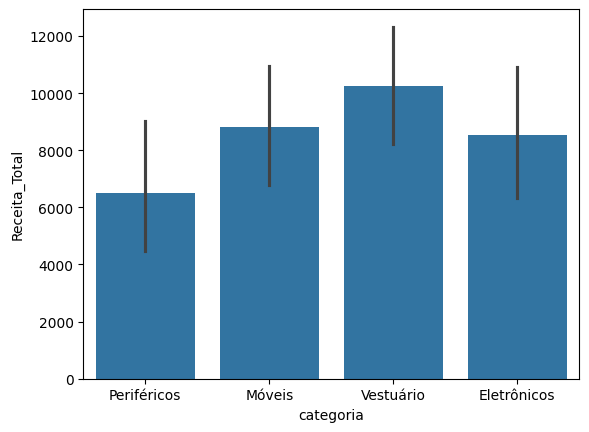

In [23]:
# Gezando vizualizações graficas
# Grafico de barras mostrando a receita por categoria
sns.barplot(x='categoria', y='Receita_Total', data=df)

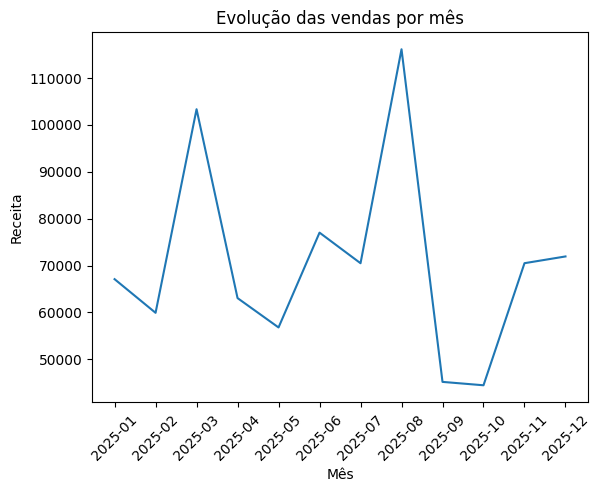

In [45]:
# Gerando grafico de linha mostrando a evolução das vendas por mês
df['data'] = pd.to_datetime(df['data'])
df['mes'] = df['data'].dt.strftime('%Y-%m')
vendas_por_mes = (
    df.groupby('mes')['Receita_Total']
    .sum()
    .reset_index(name='receita')
    .sort_values('mes')
)

sns.lineplot(x='mes', y='receita', data=vendas_por_mes)

plt.xticks(rotation=45)
plt.title('Evolução das vendas por mês')
plt.xlabel('Mês')
plt.ylabel('Receita')
plt.show()

In [ ]:
#Criando tabela dinâmica para analisar a receita total por região e categoria
tabela = df.pivot_table(
    values='Receita_Total',
    index='regiao',
    columns='categoria',
    aggfunc='sum',
    fill_value=0
)

#Exportando a tabela dinâmica para um arquivo excel
tabela.to_excel('../Resultados/receita_por_regiao_categoria.xlsx')
